In [1]:
%load_ext autoreload
%autoreload 2

In [51]:
from vasicek_poisson.config import RAW_DATA_DIR, AAA_FILENAME, ALL_BONDS_FILENAME
from vasicek_poisson.data.loader import ECBDataLoader
from vasicek_poisson.data.parser import ECBDataParser
from vasicek_poisson.data.cleaner import ECBDataCleaner

# DATA LOADING
loader = ECBDataLoader(RAW_DATA_DIR)
df = loader.load_csv(AAA_FILENAME)

df.head()
df.columns
df["DATA_TYPE_FM"].unique()

<StringArray>
[    'BETA0',     'BETA1',     'BETA2',     'BETA3',    'IF_10M',    'IF_10Y',
 'IF_10Y10M', 'IF_10Y11M',  'IF_10Y1M',  'IF_10Y2M',
 ...
   'SR_9Y2M',   'SR_9Y3M',   'SR_9Y4M',   'SR_9Y5M',   'SR_9Y6M',   'SR_9Y7M',
   'SR_9Y8M',   'SR_9Y9M',      'TAU1',      'TAU2']
Length: 1083, dtype: str

In [2]:
from vasicek_poisson.config import RAW_DATA_DIR, AAA_FILENAME, ALL_BONDS_FILENAME
from vasicek_poisson.data.loader import ECBDataLoader
from vasicek_poisson.data.parser import ECBDataParser

loader = ECBDataLoader(RAW_DATA_DIR)
parser = ECBDataParser()

df_aaa, df_all = loader.load_pair(AAA_FILENAME, ALL_BONDS_FILENAME)

aaa_spot = parser.keep_core_columns(parser.filter_spot_rates(df_aaa))
aaa_spot = parser.add_maturity_years(aaa_spot)

aaa_spot.head()

aaa_spot.columns
aaa_spot.shape
aaa_spot["maturity_years"].unique()
aaa_spot["TIME_PERIOD"].unique()[:10]

# now for the all bonds dataset
all_bonds_spot = parser.keep_core_columns(parser.filter_spot_rates(df_all))
all_bonds_spot = parser.add_maturity_years(all_bonds_spot)
all_bonds_spot.head()

all_bonds_spot.columns
all_bonds_spot.shape
all_bonds_spot["maturity_years"].unique()
all_bonds_spot["TIME_PERIOD"].unique()[:10]

<StringArray>
['2004-09-06', '2004-09-07', '2004-09-08', '2004-09-09', '2004-09-10',
 '2004-09-13', '2004-09-14', '2004-09-15', '2004-09-16', '2004-09-17']
Length: 10, dtype: str

In [3]:
#visutalize the entire df as spreadsheet
aaa_spot.tail(20)


,TIME_PERIOD,DATA_TYPE_FM,OBS_VALUE,TITLE,maturity_years
5891788,2025-12-02,SR_9Y9M,2.820288,AAA yield curve - 9-year 9-month spot rate,9.75
5891789,2025-12-03,SR_9Y9M,2.804938,AAA yield curve - 9-year 9-month spot rate,9.75
5891790,2025-12-04,SR_9Y9M,2.827433,AAA yield curve - 9-year 9-month spot rate,9.75
5891791,2025-12-05,SR_9Y9M,2.850889,AAA yield curve - 9-year 9-month spot rate,9.75
5891792,2025-12-08,SR_9Y9M,2.917326,AAA yield curve - 9-year 9-month spot rate,9.75
5891793,2025-12-09,SR_9Y9M,2.911887,AAA yield curve - 9-year 9-month spot rate,9.75
5891794,2025-12-10,SR_9Y9M,2.926709,AAA yield curve - 9-year 9-month spot rate,9.75
5891795,2025-12-11,SR_9Y9M,2.906968,AAA yield curve - 9-year 9-month spot rate,9.75
5891796,2025-12-12,SR_9Y9M,2.934230,AAA yield curve - 9-year 9-month spot rate,9.75
5891797,2025-12-15,SR_9Y9M,2.903378,AAA yield curve - 9-year 9-month spot rate,9.75


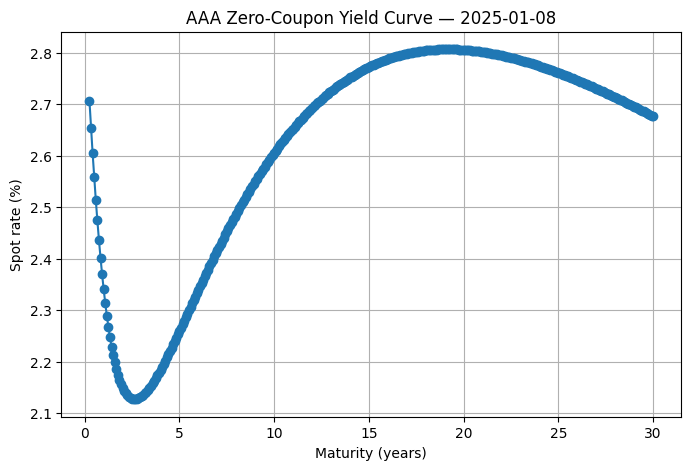

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

# ensure date is datetime
aaa_spot["TIME_PERIOD"] = pd.to_datetime(aaa_spot["TIME_PERIOD"])

# choose a date (must exist in dataset)
date = pd.Timestamp("2025-01-08")

# slice curve
curve = aaa_spot[aaa_spot["TIME_PERIOD"] == date]

# sort by maturity
curve = curve.sort_values("maturity_years")

# plot
plt.figure(figsize=(8,5))
plt.plot(curve["maturity_years"], curve["OBS_VALUE"], marker="o")
plt.xlabel("Maturity (years)")
plt.ylabel("Spot rate (%)")
plt.title(f"AAA Zero-Coupon Yield Curve — {date.date()}")
plt.grid(True)
plt.show()

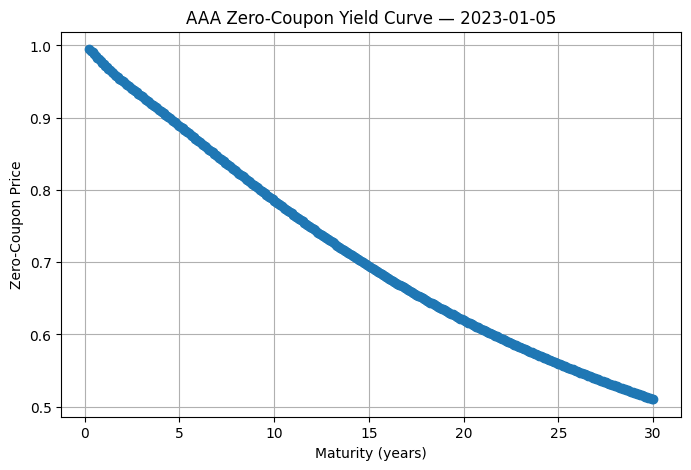

In [5]:
import numpy as np

# Calculate ZC prices for the entire curve and check for monotonicity in continuous compounding
# ensure date is datetime
aaa_spot["TIME_PERIOD"] = pd.to_datetime(aaa_spot["TIME_PERIOD"])

# choose a date (must exist in dataset)
date = pd.Timestamp("2023-01-05")

# slice curve
curve = aaa_spot[aaa_spot["TIME_PERIOD"] == date]

# sort by maturity
curve = curve.sort_values("maturity_years")

curve["ZC_price"] = np.exp(-curve["OBS_VALUE"] * curve["maturity_years"] / 100)

# plot
plt.figure(figsize=(8,5))
plt.plot(curve["maturity_years"], curve["ZC_price"], marker="o")
plt.xlabel("Maturity (years)")
plt.ylabel("Zero-Coupon Price")
plt.title(f"AAA Zero-Coupon Yield Curve — {date.date()}")
plt.grid(True)
plt.show()

In [6]:
import matplotlib.pyplot as plt
import pandas as pd


def plot_two_curves(df_aaa, df_all, date):
    date = pd.Timestamp(date)

    df_aaa = df_aaa.copy()
    df_all = df_all.copy()

    df_aaa["TIME_PERIOD"] = pd.to_datetime(df_aaa["TIME_PERIOD"])
    df_all["TIME_PERIOD"] = pd.to_datetime(df_all["TIME_PERIOD"])

    curve_aaa = df_aaa[df_aaa["TIME_PERIOD"] == date].sort_values("maturity_years")
    curve_all = df_all[df_all["TIME_PERIOD"] == date].sort_values("maturity_years")

    print("AAA points:", len(curve_aaa))
    print("ALL points:", len(curve_all))

    plt.figure(figsize=(9, 5))
    plt.plot(curve_aaa["maturity_years"], curve_aaa["OBS_VALUE"], marker="o", label="AAA")
    plt.plot(curve_all["maturity_years"], curve_all["OBS_VALUE"], marker="o", label="Aggregate")
    plt.xlabel("Maturity (years)")
    plt.ylabel("Spot rate (%)")
    plt.title(f"ECB Zero-Coupon Yield Curves — {date.date()}")
    plt.legend()
    plt.grid(True)
    plt.show()

AAA points: 358
ALL points: 358


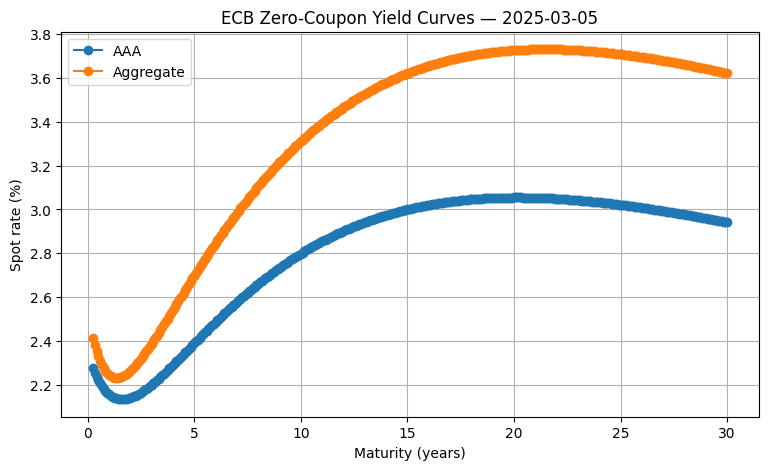

In [7]:
plot_two_curves(aaa_spot, all_bonds_spot, "2025-03-05")

AAA points: 358
ALL points: 358


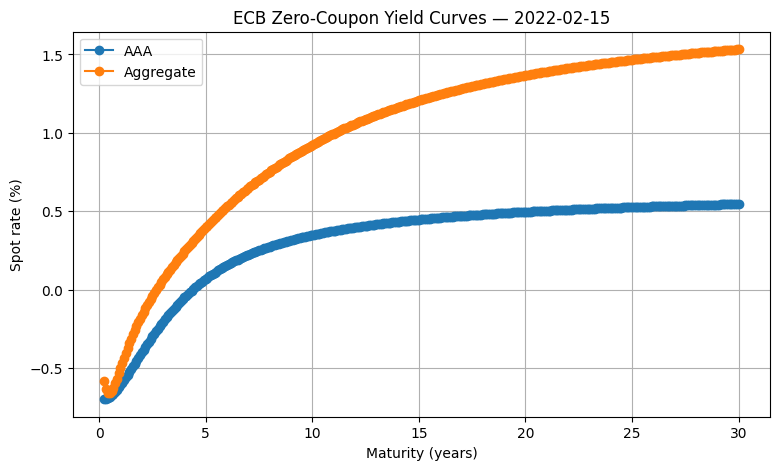

In [8]:
plot_two_curves(aaa_spot, all_bonds_spot, "2022-02-15")

In [10]:
from vasicek_poisson.data.cleaner import ECBDataCleaner

# configure cleaner (set min_maturities if you want to enforce a minimum per date)
cleaner = ECBDataCleaner(
    min_maturity=0.25,
    max_maturity=30.0,
    min_maturities=None,  # e.g., 30 to enforce a minimum
)

def clean_and_report(df, name):
    cleaned, report = cleaner.clean(df)
    print(f"{name} rows in/out: {report.rows_in} -> {report.rows_out}")
    print(f"{name} dropped missing: {report.dropped_missing_critical}")
    print(f"{name} dropped out of range: {report.dropped_out_of_range}")
    print(f"{name} dropped duplicates: {report.dropped_duplicates}")
    print(f"{name} dropped insufficient maturities: {report.dropped_insufficient_maturities}")
    return cleaned, report

aaa_clean, aaa_report = clean_and_report(aaa_spot, "AAA")
all_clean, all_report = clean_and_report(all_bonds_spot, "ALL")

aaa_clean.head()


AAA rows in/out: 1951100 -> 1951100
AAA dropped missing: 0
AAA dropped out of range: 0
AAA dropped duplicates: 0
AAA dropped insufficient maturities: 0
ALL rows in/out: 1951100 -> 1951100
ALL dropped missing: 0
ALL dropped out of range: 0
ALL dropped duplicates: 0
ALL dropped insufficient maturities: 0


,TIME_PERIOD,DATA_TYPE_FM,OBS_VALUE,TITLE,maturity_years
0,2004-09-06,SR_3M,2.034172,AAA yield curve - 3-month spot rate,0.250000
1,2004-09-06,SR_4M,2.063283,AAA yield curve - 4-month spot rate,0.333333
2,2004-09-06,SR_5M,2.092544,AAA yield curve - 5-month spot rate,0.416667
3,2004-09-06,SR_6M,2.121920,AAA yield curve - 6-month spot rate,0.500000
4,2004-09-06,SR_7M,2.151377,AAA yield curve - 7-month spot rate,0.583333


In [11]:
import pandas as pd

from vasicek_poisson.data.builder import ECBDataBuilder
from vasicek_poisson.data.cleaner import ECBDataCleaner
from vasicek_poisson.market import MarketSnapshot

cleaner = ECBDataCleaner(min_maturity=0.25, max_maturity=30.0, min_maturities=None)
builder = ECBDataBuilder(cleaner=cleaner)

aaa_result = builder.build_cleaned_spot_panel(df_aaa)
all_result = builder.build_cleaned_spot_panel(df_all)


def inspect_panel(df: pd.DataFrame, name: str) -> None:
    frame = df.copy()
    frame["TIME_PERIOD"] = pd.to_datetime(frame["TIME_PERIOD"], errors="coerce")
    summary = frame.groupby("TIME_PERIOD")["maturity_years"].nunique()
    print(
        f"{name} rows: {len(frame)}, dates: {summary.size}, "
        f"maturity range: {frame['maturity_years'].min():.2f}-"
        f"{frame['maturity_years'].max():.2f}"
    )
    print(f"{name} median maturities per date: {summary.median():.0f}")


inspect_panel(aaa_result.cleaned, "AAA cleaned")
inspect_panel(all_result.cleaned, "ALL cleaned")

sample_date = pd.Timestamp(aaa_result.cleaned["TIME_PERIOD"].iloc[0])
snapshot = MarketSnapshot.from_cleaned_panel(aaa_result.cleaned, sample_date)
snapshot.risk_free_curve.to_frame().head()


AAA cleaned rows: 1951100, dates: 5450, maturity range: 0.25-30.00
AAA cleaned median maturities per date: 358
ALL cleaned rows: 1951100, dates: 5450, maturity range: 0.25-30.00
ALL cleaned median maturities per date: 358


,TIME_PERIOD,maturity_years,OBS_VALUE
0,2004-09-06,0.250000,2.034172
1,2004-09-06,0.333333,2.063283
2,2004-09-06,0.416667,2.092544
3,2004-09-06,0.500000,2.121920
4,2004-09-06,0.583333,2.151377
